[Previous: GoF 4: Behavioral Patterns, Part 1](04_Behavioral_Part_1.ipynb)  |  [Course Index](../00_Start_Here.ipynb)  |  [Next: GoF 6: Behavioral Patterns, Part 3](06_Behavioral_Part_3.ipynb)

# GoF 5: Behavioral Patterns, Part 2

**Learning objectives.** After this module you can:

* implement Observer so one object notifies many without knowing them, and trace the notifications;
* replace a pile of `if state == ...` with State objects and draw the state diagram;
* swap algorithms at runtime with Strategy, and know when a function is all you need;
* snapshot and restore an object with Memento without exposing its internals.

## 1. Observer

**Problem.** When a stock price changes, a chart, a logger and an alert must all react. The price object should not know or care which ones exist.

**Structure.** The subject keeps a list of observers and calls `update` on each when it changes. Observers register and unregister themselves.

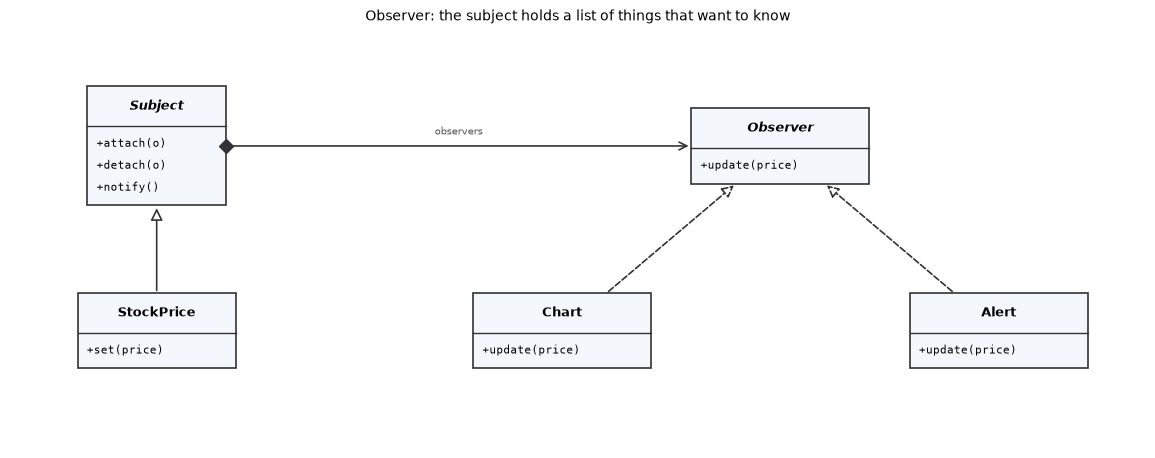

In [1]:
from dplab import class_diagram, state_diagram, traced, trace

class_diagram(
    {"Subject": ["+attach(o)", "+detach(o)", "+notify()"], "StockPrice": ["+set(price)"], "Observer": ["+update(price)"],
     "Chart": ["+update(price)"], "Alert": ["+update(price)"]},
    [("StockPrice", "Subject", "inherits"), ("Chart", "Observer", "implements"), ("Alert", "Observer", "implements"), ("Subject", "Observer", "has", "observers")],
    abstract={"Subject", "Observer"}, layout={"Subject": (-1, 0), "Observer": (1, 0), "StockPrice": (-1, 1), "Chart": (0.3, 1), "Alert": (1.7, 1)},
    title="Observer: the subject holds a list of things that want to know")

  ALERT: 105 above 100
chart points: [95, 105, 120]


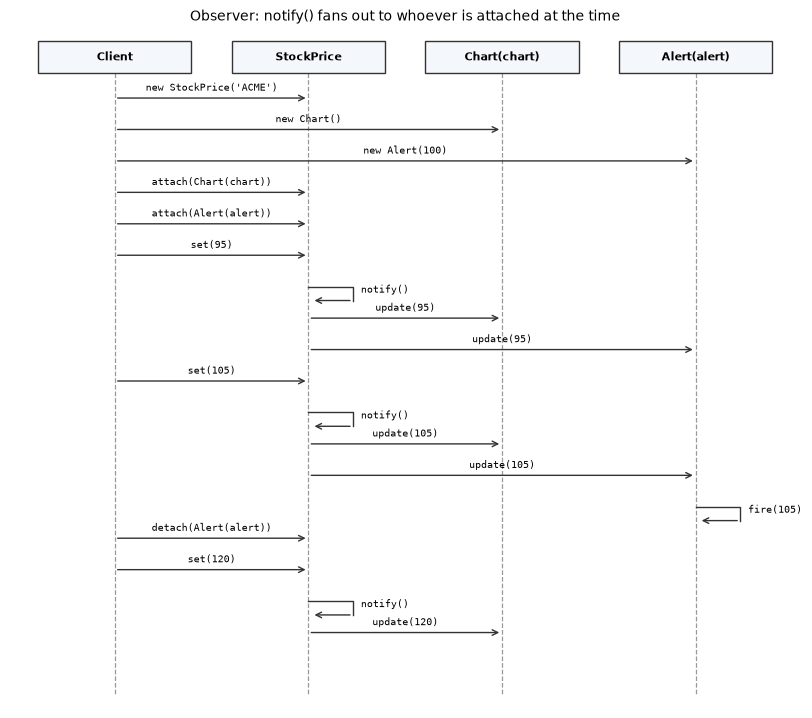

In [2]:
@traced
class StockPrice:
    def __init__(self, symbol):
        self.symbol, self.price, self.observers = symbol, 0.0, []

    def attach(self, observer):  self.observers.append(observer)
    def detach(self, observer):  self.observers.remove(observer)

    def set(self, price):
        self.price = price
        self.notify()

    def notify(self):
        for obs in list(self.observers):          # copy: an observer may detach itself during the loop
            obs.update(self.price)

@traced
class Chart:
    name = "chart"
    def __init__(self): self.points = []
    def update(self, price): self.points.append(price)

@traced
class Alert:
    name = "alert"
    def __init__(self, threshold): self.threshold = threshold
    def update(self, price):
        if price > self.threshold:
            self.fire(price)
    def fire(self, price): print(f"  ALERT: {price} above {self.threshold}")

with trace() as t:
    acme = StockPrice("ACME")
    chart, alert = Chart(), Alert(100)
    acme.attach(chart); acme.attach(alert)
    acme.set(95); acme.set(105)
    acme.detach(alert)
    acme.set(120)
print("chart points:", chart.points)
t.diagram(title="Observer: notify() fans out to whoever is attached at the time", max_messages=30)

### Lab: Observer Lab

A thermostat with three optional observers. Move the temperature, attach and detach, and watch the traced sequence diagram change.

Observer Lab (static preview). Run this cell in JupyterLab for the interactive version.


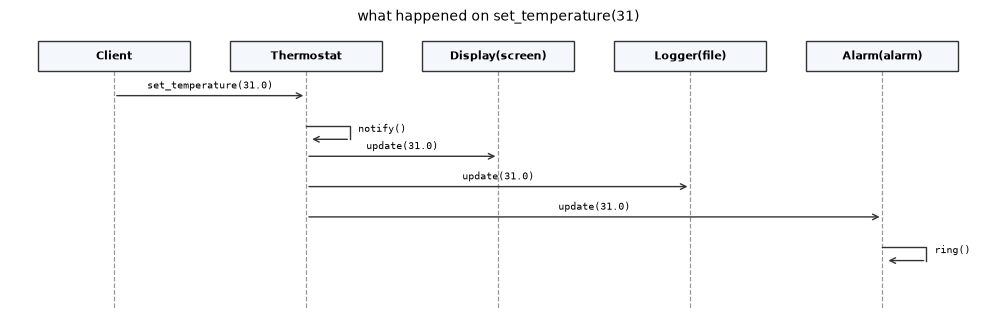

In [3]:
from dplab import observer_lab

observer_lab()

## 2. State

**Problem.** A turnstile behaves differently when locked and when unlocked, and the `if self.state == "locked"` checks multiply with every new state and event.

**Structure.** One class per state, each implementing the events. The context delegates to its current state object and swaps it when a transition happens.

push  -> still locked                     now Locked
coin  -> unlocked                         now Unlocked
coin  -> already unlocked, coin returned  now Unlocked
push  -> passed through, locked again     now Locked
push  -> still locked                     now Locked


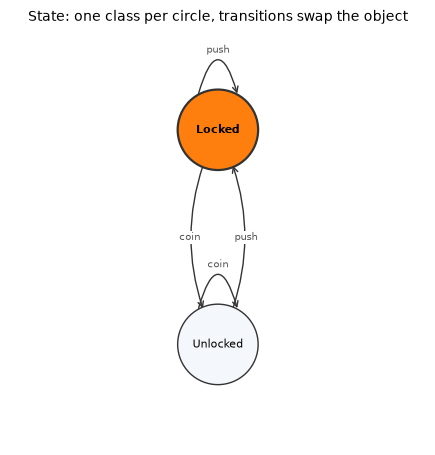

In [4]:
class Locked:
    def coin(self, t):  t.state = Unlocked(); return "unlocked"
    def push(self, t):  return "still locked"

class Unlocked:
    def coin(self, t):  return "already unlocked, coin returned"
    def push(self, t):  t.state = Locked(); return "passed through, locked again"

class Turnstile:                                       # the context
    def __init__(self): self.state = Locked()
    def coin(self):  return self.state.coin(self)      # no if statements: the state object decides
    def push(self):  return self.state.push(self)

t = Turnstile()
for event in ["push", "coin", "coin", "push", "push"]:
    print(f"{event:<5} -> {getattr(t, event)():<32} now {type(t.state).__name__}")

state_diagram(["Locked", "Unlocked"], [("Locked", "coin", "Unlocked"), ("Locked", "push", "Locked"), ("Unlocked", "push", "Locked"), ("Unlocked", "coin", "Unlocked")],
              current=type(t.state).__name__, title="State: one class per circle, transitions swap the object")

### Lab: State Machine Lab

Fire events at a turnstile, an order lifecycle or a traffic light. The diagram highlights the current state and the log shows ignored events.

State Machine Lab (static preview). Run this cell in JupyterLab for the interactive version.


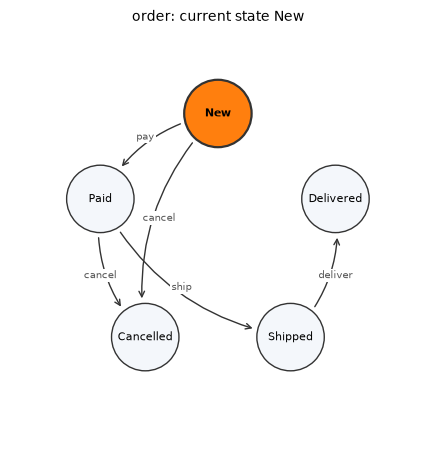

In [5]:
from dplab import state_machine_lab

state_machine_lab("order")

## 3. Strategy

**Problem.** Shipping cost can be computed by weight, by flat rate or by zone, and the rule is chosen at runtime. Hard-coding the choice into the order class spreads `if` statements everywhere.

**Structure.** Each algorithm is an interchangeable object with one method; the context holds one and calls it. In Python, that object is very often just a **function**.

In [6]:
# Class form
class ByWeight:
    def cost(self, order):  return 2.0 * order["kg"]

class FlatRate:
    def cost(self, order):  return 7.5

class ByZone:
    def __init__(self, rates): self.rates = rates
    def cost(self, order):  return self.rates[order["zone"]]

class Checkout:
    def __init__(self, strategy): self.strategy = strategy
    def total(self, order):  return order["items"] + self.strategy.cost(order)

order = {"items": 40.0, "kg": 3, "zone": "EU"}
for s in (ByWeight(), FlatRate(), ByZone({"EU": 5, "US": 12})):
    print(f"{type(s).__name__:<9} total {Checkout(s).total(order):.2f}")

# Function form: the same thing, and what most Python code actually does
strategies = {"weight": lambda o: 2.0 * o["kg"], "flat": lambda o: 7.5, "zone": lambda o: {"EU": 5, "US": 12}[o["zone"]]}
def total(order, shipping):
    return order["items"] + shipping(order)
print("\nfunctions:", {name: total(order, fn) for name, fn in strategies.items()})
print("sorted(key=...) is Strategy too:", sorted(["pear", "fig", "banana"], key=len))

ByWeight  total 46.00
FlatRate  total 47.50
ByZone    total 45.00

functions: {'weight': 46.0, 'flat': 47.5, 'zone': 45.0}
sorted(key=...) is Strategy too: ['fig', 'pear', 'banana']


## 4. Memento

**Problem.** Save an object's state so it can be restored later (undo, checkpoints), without letting the saver see or depend on the object's internals.

**Structure.** The originator produces an opaque memento and can restore from one; a caretaker stores mementos and never looks inside.

In [7]:
class TextEditor:                                        # originator
    def __init__(self): self._text, self._cursor = "", 0
    def type(self, s):
        self._text = self._text[:self._cursor] + s + self._text[self._cursor:]
        self._cursor += len(s)
    def save(self):                                      # memento: a tuple the caretaker cannot meaningfully inspect
        return (self._text, self._cursor)
    def restore(self, memento):
        self._text, self._cursor = memento
    def __repr__(self): return f"{self._text!r} cursor={self._cursor}"

class Caretaker:
    def __init__(self, editor): self.editor, self.history = editor, []
    def checkpoint(self): self.history.append(self.editor.save())
    def undo(self):
        if self.history: self.editor.restore(self.history.pop())

ed = TextEditor(); care = Caretaker(ed)
ed.type("hello"); care.checkpoint()
ed.type(" world"); care.checkpoint()
ed.type("!!!")
print("now:      ", ed)
care.undo(); print("undo once:", ed)
care.undo(); print("undo twice:", ed)

now:       'hello world!!!' cursor=14
undo once: 'hello world' cursor=11
undo twice: 'hello' cursor=5


> **What to notice.** The caretaker holds tuples it never reads. Command (Module 4) often uses a memento for its `undo`: the two patterns are frequent partners.

## Try it yourself

**Exercise 1.** Add an observer that detaches itself after the first update. Does the loop in `notify` survive it? Remove the `list(...)` copy and see.

**Exercise 2.** Add a `Broken` state to the turnstile reachable by a `kick` event from either state, from which nothing works until `repair`. Redraw the diagram.

**Exercise 3.** Write a Strategy for a text formatter: `left`, `right`, `centre` alignment as functions, chosen by name.

**Exercise 4 (challenge).** Make the Memento immutable and hashable so the caretaker can deduplicate identical consecutive checkpoints.

<details><summary>Solutions</summary>

```python
# Exercise 1
class OneShot:
    def __init__(self, subject): self.subject = subject
    def update(self, price): print("one shot", price); self.subject.detach(self)
# Without the copy, removing during iteration skips the next observer.

# Exercise 2
class Broken:
    def coin(self, t):  return "broken, coin returned"
    def push(self, t):  return "broken"
    def repair(self, t): t.state = Locked(); return "repaired"
for cls in (Locked, Unlocked):
    cls.kick = lambda self, t: (setattr(t, "state", Broken()), "broken now")[1]
    cls.repair = lambda self, t: "not broken"
Turnstile.kick = lambda self: self.state.kick(self)
Turnstile.repair = lambda self: self.state.repair(self)

# Exercise 3
align = {"left": str.ljust, "right": str.rjust, "centre": str.center}
print(align["centre"]("hi", 10, "."))

# Exercise 4: a tuple is already immutable and hashable; in checkpoint(), skip if self.history and self.history[-1] == memento.
```

</details>

## Checkpoint quiz

Four quick questions. Answer them before reading the takeaways. If you miss one, the explanation points you to the section to re-read.

In [8]:
from dplab import quiz

quiz(5)

Checkpoint quiz, Module 5 (static preview). Run this cell in JupyterLab to answer interactively.

Q1. Observer
    a) lets one object notify many dependents when it changes
    b) copies objects
    c) chains handlers
    d) adds behaviour

Q2. The State pattern changes an object's behaviour by
    a) a chain of if statements
    b) delegating to a state object and swapping it on transitions
    c) subclassing the context
    d) copying the object

Q3. The most Pythonic Strategy is often
    a) an abstract base class with one method
    b) a plain function passed as an argument
    c) a singleton
    d) a metaclass

Q4. A Memento stores
    a) a snapshot of an object's state without exposing its internals
    b) the command history
    c) a shared flyweight
    d) a proxy


## Key takeaways

* Observer: a subject fans out change notifications to a list it does not inspect; copy the list before iterating.
* State: one class per state, the context delegates and swaps; the state diagram is the specification.
* Strategy: interchangeable algorithms; in Python usually functions, and `key=` arguments are the everyday example.
* Memento: opaque snapshots held by a caretaker; the usual engine behind undo.

**Next:** Template Method, Visitor and Interpreter. [GoF 6](06_Behavioral_Part_3.ipynb).

[Previous: GoF 4: Behavioral Patterns, Part 1](04_Behavioral_Part_1.ipynb)  |  [Course Index](../00_Start_Here.ipynb)  |  [Next: GoF 6: Behavioral Patterns, Part 3](06_Behavioral_Part_3.ipynb)